### Analysis on a nodule section ###

In [1]:
import os
import re
import anndata as ad
import pandas as pd
import scanpy as sc
import numpy as np
import scipy.sparse as sp
from kneed import KneeLocator
import matplotlib.pyplot as plt
from kneed import KneeLocator
from collections import defaultdict, deque
from gei_nj import comb_depth_ratio, filt_snv_by_depth_ratio, add_callable_layer, revise_snv_ratio, impute_non_callable_by_snv_mean, build_and_plot_nj, comb_depth_ratio, plot_snv_pca_by_group

Set colors of branches

In [2]:
group_colors = {'Early_nodule_cortex':'#a6d96a', 'Infected_Zone':'#f8766d',
                'Meristems':'#336699', 'Vascular_tissue':'#fdb863','Peripheral_tissues':'#9970ab'}

Process data

In [3]:
## Load in SNV ratio and depth of a dataset
ad_depth = ad.read_h5ad("01.Data/Nodule_section2_new_anno/unit_depth.h5ad")
ad_ratio = ad.read_h5ad("01.Data/Nodule_section2_new_anno/unit_ratio.h5ad")

## Combine depth and ratio to a combined adata
adata = comb_depth_ratio(ad_depth, ad_ratio)

## Filter SNVs based on depth and ratio
adata = filt_snv_by_depth_ratio(adata, min_tot_depth=20, min_mut_depth=5, min_mut_avg_ratio=0.1)

SNV number before filter: 22944
SNV number after filter: 1971


In [4]:
adata.obs["group"] = adata.obs_names.astype(str)

Construct callable layer based on depth

In [5]:
adata = add_callable_layer(adata, min_callable_depth=3)

Callable layer added to adata.layers['callable']
Minimum callable depth: 3
Total SNV entries: 9855
Callable SNV entries: 9088
Global callable fraction: 0.9222


In [6]:
## change SNV ratio (adata.X) to 0, 0.5 and 1. By default, the original SNV ratio will be moved to the 'original_ratio' layer.
adata = revise_snv_ratio(adata) 

In [7]:
adata = impute_non_callable_by_snv_mean(adata, callable_layer="callable", output_layer="geinj_state_imputed",)

Non-callable entries imputed by per-SNV callable mean
Callable entries: 9088
Non-callable entries: 767
Total SNV entries: 9855
Imputed matrix stored in adata.layers['geinj_state_imputed']
adata.X was updated to the imputed matrix


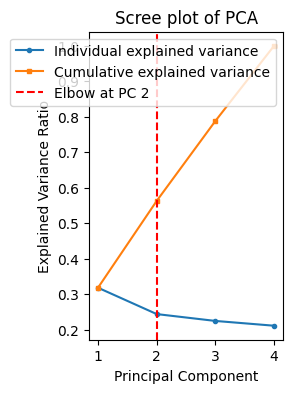

In [8]:
n_comps = min(adata.n_obs-1, adata.n_vars, 50)
sc.pp.pca(adata, n_comps=n_comps)
explained_var = adata.uns['pca']['variance_ratio']
explained_var_cum = explained_var.cumsum()

# Detect elbow point
kl = KneeLocator(range(1, len(explained_var)+1), explained_var, curve="convex", direction="decreasing")
elbow_PC = kl.elbow

plt.figure(figsize=(2.5,4))
plt.plot(range(1, len(explained_var)+1), explained_var, 'o-', markersize=3, label="Individual explained variance")
plt.plot(range(1, len(explained_var)+1), explained_var_cum, 's-', markersize=3, label="Cumulative explained variance")
plt.axvline(elbow_PC, color='r', linestyle='--', label=f'Elbow at PC {elbow_PC}')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.legend()
plt.title('Scree plot of PCA')
plt.savefig("00.Plots_Backup/Nodule/Nodule_sec_elbow_plot.pdf", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

<Figure size 1000x300 with 0 Axes>

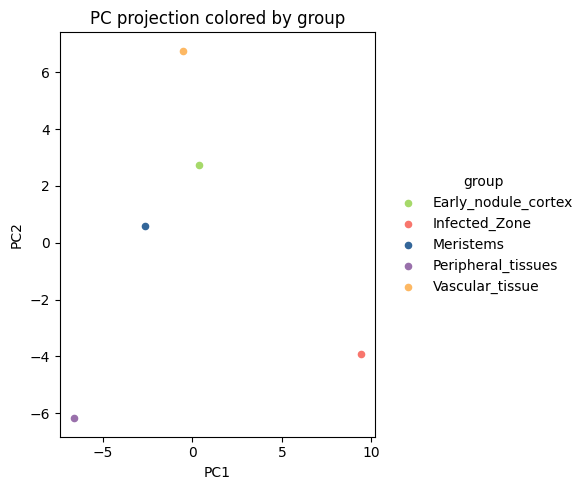

In [9]:
plt.figure(figsize=(10,3))
plot_snv_pca_by_group(adata, pcx=1, pcy=2, alpha=1, group_by="group", size=20, group_colors=group_colors, savepath="00.Plots_Backup/Nodule/Nodule_sec_PC1_PC2.pdf")

Plot NJ trees and color branches
PCA based GEI-NJ tree constructed from imputed revised expressed SNV states.

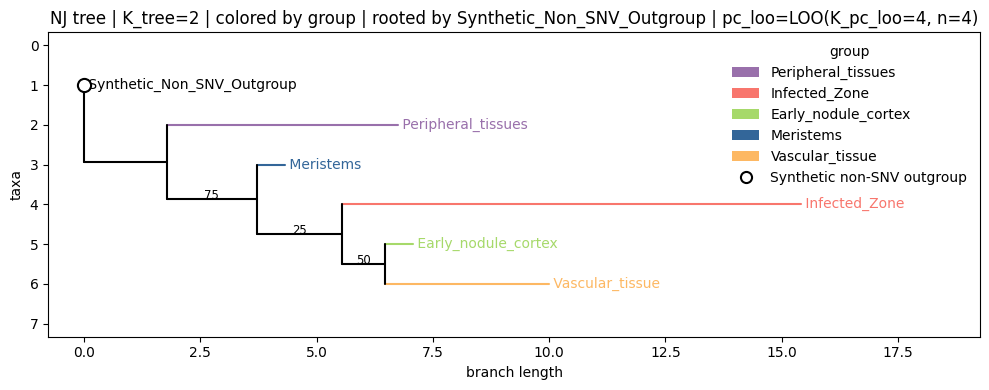

In [10]:
tree = build_and_plot_nj(adata, figsize=(10, 4), pc_loo=True, K_tree=2, K_pc_loo=10, 
                          pc_loo_min_support=25, group_key="group", savepath="00.Plots_Backup/Nodule/Nodule_Infected_PC1-2_NJtree.pdf",
                          group_colors=group_colors, show_leaf_labels=True, show_legend=True)

In [ ]:
tree = build_and_plot_nj(adata, figsize=(10, 4), pc_loo=True, K_tree=3, K_pc_loo=10, 
                          pc_loo_min_support=25, group_key="group", savepath="00.Plots_Backup/Nodule/Nodule_Infected_PC1-3_NJtree.pdf",
                          group_colors=group_colors, show_leaf_labels=True, show_legend=True)

Test no imputation

SNV number before filter: 22944
SNV number after filter: 1971
Non-callable entries imputed by per-SNV callable mean
Callable entries: 9855
Non-callable entries: 0
Total SNV entries: 9855
Imputed matrix stored in adata.layers['geinj_state_no_impute']
adata.X was updated to the imputed matrix


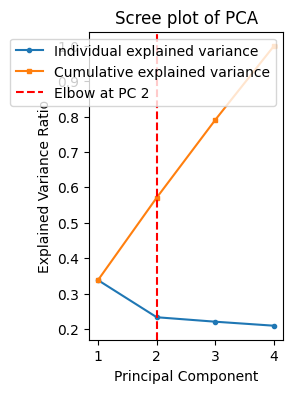

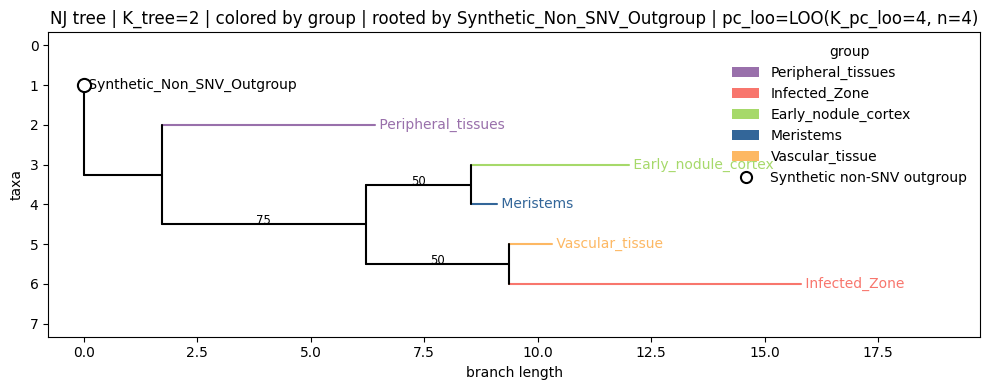

In [11]:
## Load in SNV ratio and depth of a dataset
ad_depth = ad.read_h5ad("01.Data/Nodule_section2_new_anno/unit_depth.h5ad")
ad_ratio = ad.read_h5ad("01.Data/Nodule_section2_new_anno/unit_ratio.h5ad")

## Combine depth and ratio to a combined adata
adata2 = comb_depth_ratio(ad_depth, ad_ratio)

## Filter SNVs based on depth and ratio
adata2 = filt_snv_by_depth_ratio(adata2, min_tot_depth=20, min_mut_depth=5, min_mut_avg_ratio=0.1)

adata2.obs["group"] = adata2.obs_names.astype(str)

adata2.layers["callable_all1"] = np.ones(adata2.shape, dtype=np.int8)

adata2 = impute_non_callable_by_snv_mean(
    adata2,
    callable_layer="callable_all1",
    output_layer="geinj_state_no_impute"
)

n_comps = min(adata2.n_obs-1, adata2.n_vars, 50)
sc.pp.pca(adata2, n_comps=n_comps)
explained_var = adata2.uns['pca']['variance_ratio']
explained_var_cum = explained_var.cumsum()

# Detect elbow point
kl = KneeLocator(range(1, len(explained_var)+1), explained_var, curve="convex", direction="decreasing")
elbow_PC = kl.elbow

plt.figure(figsize=(2.5,4))
plt.plot(range(1, len(explained_var)+1), explained_var, 'o-', markersize=3, label="Individual explained variance")
plt.plot(range(1, len(explained_var)+1), explained_var_cum, 's-', markersize=3, label="Cumulative explained variance")
plt.axvline(elbow_PC, color='r', linestyle='--', label=f'Elbow at PC {elbow_PC}')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.legend()
plt.title('Scree plot of PCA')
plt.show()
plt.close()

tree2 = build_and_plot_nj(adata2, figsize=(10, 4), pc_loo=True, K_tree=2, K_pc_loo=10, 
                          pc_loo_min_support=25, group_key="group",  savepath="00.Plots_Backup/Nodule/Nodule_Infected_noimpute_PC1-2_NJtree.pdf",
                          group_colors=group_colors, show_leaf_labels=True, show_legend=True)